# Summary Tables

This notebook generates summary tables from the prioritized variant list, which combines cardiovascular association results with gnomAD variant frequency data

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

In [2]:
prioritized_path = Path("../data/final/prioritized_variants.csv")

out_dir     = Path("../data/final/")
figures_dir = Path("../data/final/figures")

out_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

out_xlsx = out_dir / "summary_tables.xlsx"

In [3]:
prioritized_df = pd.read_csv(prioritized_path, sep=";", low_memory=False)

print(f"Prioritized variants loaded: {prioritized_df.shape[0]:,} rows, {prioritized_df.shape[1]} columns")
print(f"Unique rsIDs: {prioritized_df['rsID'].nunique():,}")
print(f"Unique genes: {prioritized_df['gene'].nunique():,}")

Prioritized variants loaded: 225,358 rows, 21 columns
Unique rsIDs: 49,050
Unique genes: 51


## Summary 1: Associations per gene and dataset

In [4]:
source_phenotype_order = [
    ("GWAS Catalog",      ""),
    ("HERMES",            "Heart failure"),
    ("CARDIoGRAMplusC4D", "Coronary artery disease"),
    ("CARDIoGRAMplusC4D", "Myocardial infarction"),
    ("FinnGen",           "Heart failure"),
    ("FinnGen",           "Coronary artery disease"),
    ("FinnGen",           "Myocardial infarction"),
]

column_labels = [
    "GWAS Catalog",
    "HERMES (HF)",
    "CARDIoGRAMplusC4D (CAD)",
    "CARDIoGRAMplusC4D (MI)",
    "FinnGen (HF)",
    "FinnGen (CAD)",
    "FinnGen (MI)",
]

all_genes = sorted(prioritized_df["gene"].dropna().unique())
summary_rows = []

for gene in all_genes:
    gene_df = prioritized_df[prioritized_df["gene"] == gene]
    row = {"Gene": gene}

    for (source, trait), label in zip(source_phenotype_order, column_labels):
        if source == "GWAS Catalog":
            count = int((gene_df["source_dataset"] == source).sum())
        else:
            count = int(
                ((gene_df["source_dataset"] == source) &
                 (gene_df["phenotype"] == trait)).sum()
            )
        row[label] = count

    row["Total"] = int(gene_df.shape[0])
    summary_rows.append(row)

associations_per_gene_df = pd.DataFrame(summary_rows).set_index("Gene")

total_row = associations_per_gene_df.sum(axis=0).rename("Total").to_frame().T
total_row.index.name = "Gene"
associations_per_gene_df = pd.concat([associations_per_gene_df, total_row])

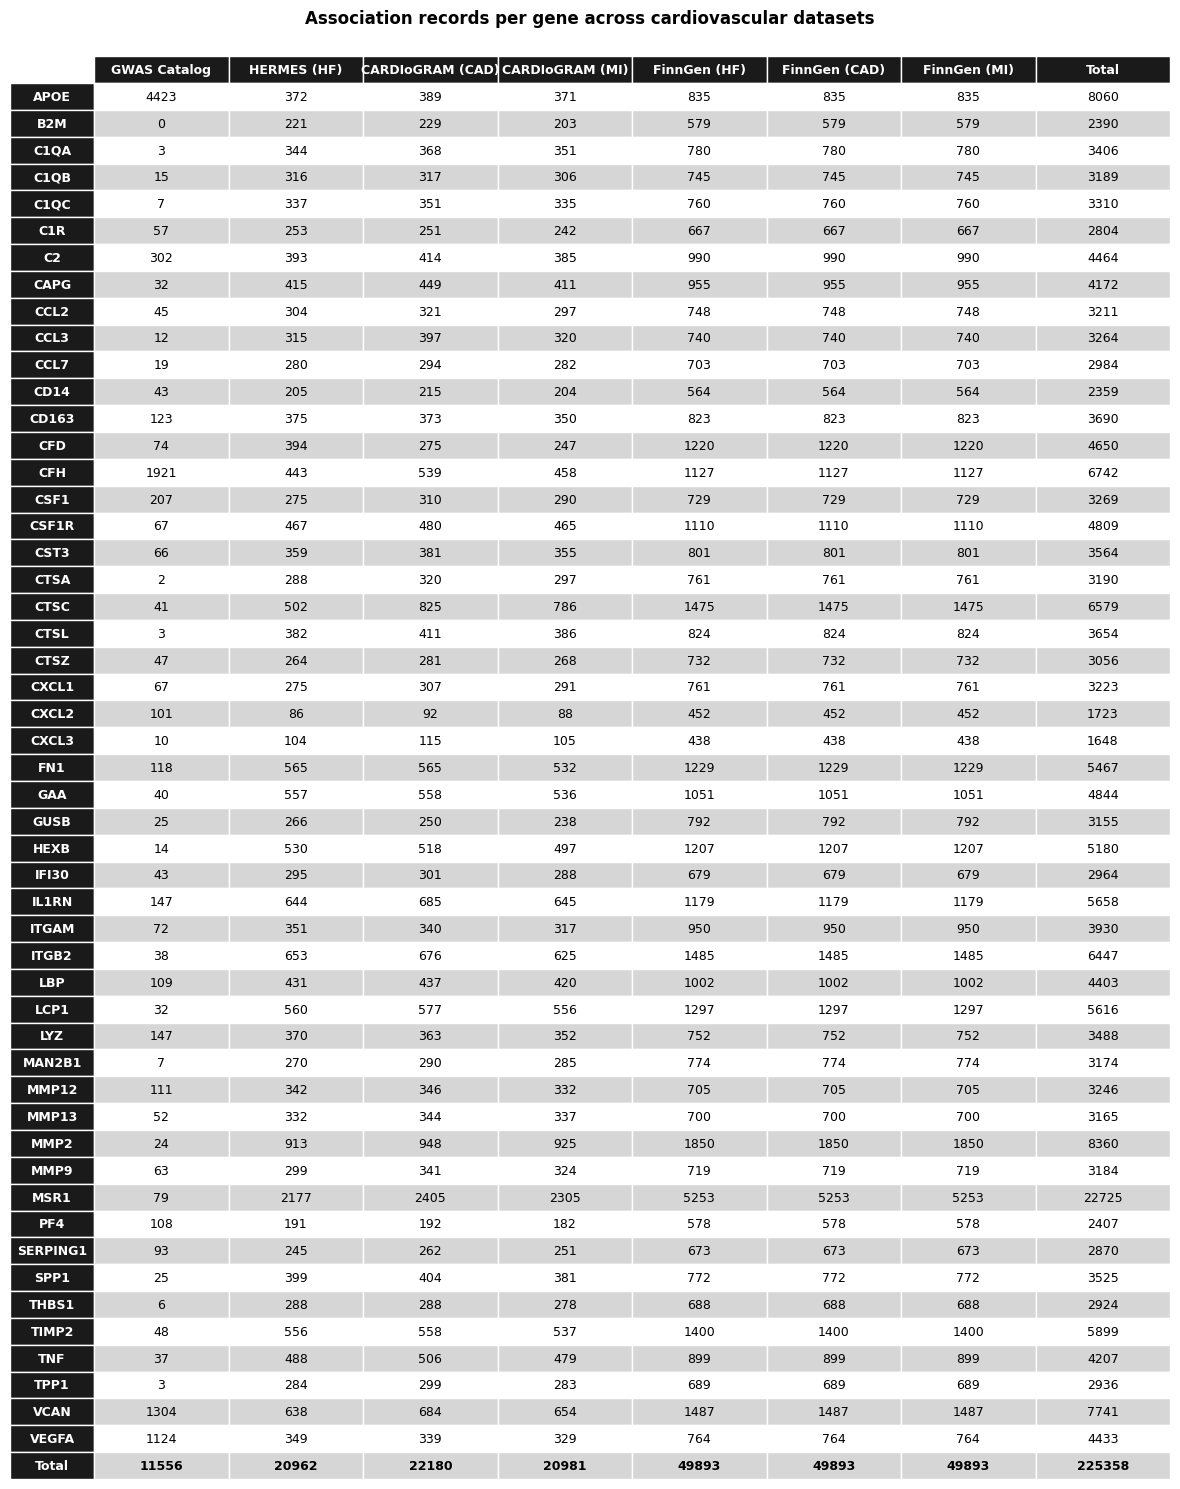

Table saved to: ../data/final/figures/prioritized_variants_table.png


In [16]:
display_labels = [
    "GWAS Catalog",
    "HERMES (HF)",
    "CARDIoGRAM (CAD)",
    "CARDIoGRAM (MI)",
    "FinnGen (HF)",
    "FinnGen (CAD)",
    "FinnGen (MI)",
    "Total",
]

n_rows, n_cols = associations_per_gene_df.shape
row_labels     = associations_per_gene_df.index.tolist()

fig_w = n_cols * 1.3 + 1.5
fig_h = (n_rows + 1) * 0.28

fig, ax = plt.subplots(figsize=(fig_w, fig_h))
ax.axis("off")

cell_text = associations_per_gene_df.values.astype(int).tolist()

table = ax.table(
    cellText  = cell_text,
    rowLabels = row_labels,
    colLabels = display_labels,
    loc       = "center",
    cellLoc   = "center",
    rowLoc    = "center",
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.6)

for col_idx in range(n_cols):
    cell = table[0, col_idx]
    cell.set_facecolor("#1a1a1a")
    cell.set_text_props(
        color      = "white",
        fontweight = "bold",
        fontsize   = 9,
    )
    cell.set_edgecolor("white")

for row_idx in range(1, n_rows + 1):
    gene_name    = row_labels[row_idx - 1]
    is_total_row = gene_name == "Total"
    row_bg       = "#d6d6d6" if row_idx % 2 == 0 else "white"

    row_label_cell = table[row_idx, -1]
    row_label_cell.set_facecolor("#1a1a1a")
    row_label_cell.set_text_props(
        fontstyle  = "normal",
        fontweight = "bold",
        color      = "white",
        fontsize   = 9,
    )
    row_label_cell.set_edgecolor("white")

    for col_idx in range(n_cols):
        cell = table[row_idx, col_idx]
        cell.set_facecolor(row_bg)
        cell.set_edgecolor("white")
        cell.set_text_props(
            fontweight = "bold" if is_total_row else "normal",
            color      = "black",
            fontsize   = 9,
        )

fig.suptitle(
    "Association records per gene across cardiovascular datasets",
    fontsize=12, fontweight="bold", y=1
)

plt.tight_layout()

table_out = figures_dir / "prioritized_variants_table.png"
fig.savefig(table_out, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

print(f"Table saved to: {table_out}")

## Summary 2: Significant associations by p-value threshold

In [6]:
thresholds = {
    "p < 5e-08 (genome-wide)": 5e-8,
    "p < 1e-05 (suggestive)":  1e-5,
    "p < 0.05 (nominal)":      0.05,
}

sig_rows = []

for gene in all_genes:
    gene_df = prioritized_df[prioritized_df["gene"] == gene]
    row = {"Gene": gene}

    for label, threshold in thresholds.items():
        row[label] = int((gene_df["p_value"] < threshold).sum())

    row["Total associations"] = int(gene_df.shape[0])
    sig_rows.append(row)

significant_associations_df = pd.DataFrame(sig_rows).set_index("Gene")

total_row = significant_associations_df.sum(axis=0).rename("Total").to_frame().T
total_row.index.name = "Gene"
significant_associations_df = pd.concat([significant_associations_df, total_row])

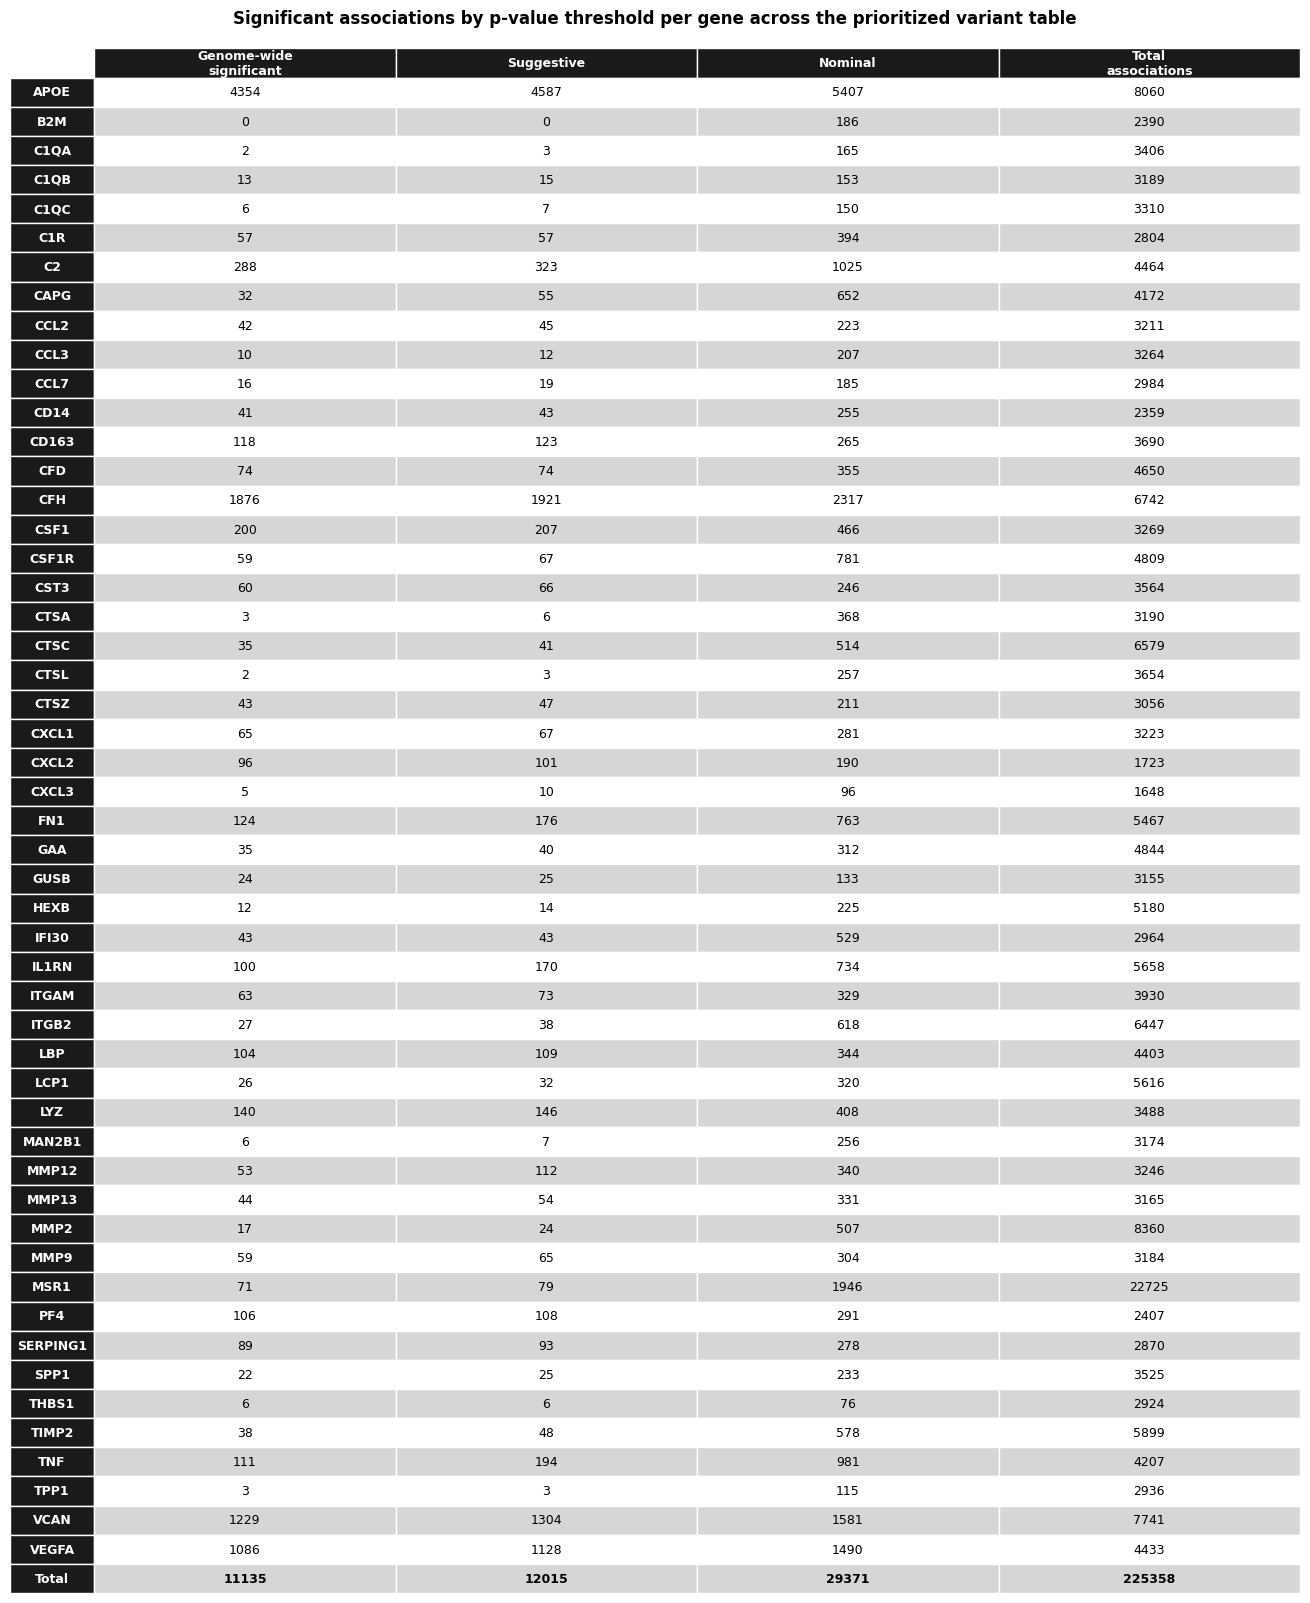

Table saved to: ../data/final/figures/significant_associations_table.png


In [15]:
display_labels = [
    "Genome-wide\nsignificant",
    "Suggestive",
    "Nominal",
    "Total\nassociations",
]

n_rows, n_cols = significant_associations_df.shape
row_labels     = significant_associations_df.index.tolist()

fig_w = n_cols * 2.8 + 2.0
fig_h = (n_rows + 1) * 0.30

fig, ax = plt.subplots(figsize=(fig_w, fig_h))
ax.axis("off")

cell_text = significant_associations_df.values.astype(int).tolist()

table = ax.table(
    cellText  = cell_text,
    rowLabels = row_labels,
    colLabels = display_labels,
    loc       = "center",
    cellLoc   = "center",
    rowLoc    = "center",
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.6)

for col_idx in range(n_cols):
    cell = table[0, col_idx]
    cell.set_facecolor("#1a1a1a")
    cell.set_text_props(
        color      = "white",
        fontweight = "bold",
        fontsize   = 9,
    )
    cell.set_edgecolor("white")

for row_idx in range(1, n_rows + 1):
    gene_name    = row_labels[row_idx - 1]
    is_total_row = gene_name == "Total"
    row_bg       = "#d6d6d6" if row_idx % 2 == 0 else "white"

    # Row label cell (gene name or Total)
    row_label_cell = table[row_idx, -1]
    row_label_cell.set_facecolor("#1a1a1a")
    row_label_cell.set_text_props(
        fontstyle  = "normal",
        fontweight = "bold",
        color      = "white",
        fontsize   = 9,
    )
    row_label_cell.set_edgecolor("white")

    for col_idx in range(n_cols):
        cell = table[row_idx, col_idx]
        cell.set_facecolor(row_bg)
        cell.set_edgecolor("white")
        cell.set_text_props(
            fontweight = "bold" if is_total_row else "normal",
            color      = "black",
            fontsize   = 9,
        )

fig.suptitle(
    "Significant associations by p-value threshold per gene across the prioritized variant table",
    fontsize=12, fontweight="bold", y=1
)

plt.tight_layout()

table_out = figures_dir / "significant_associations_table.png"
fig.savefig(table_out, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

print(f"Table saved to: {table_out}")

## Summary 3: Functional consequence categories

In [7]:
consequence_df = (
    prioritized_df
    .drop_duplicates(subset=["rsID", "functional_consequence"])
    .groupby(["gene", "functional_consequence"])
    .size()
    .reset_index(name="variant_count")
    .pivot(
        index="gene",
        columns="functional_consequence",
        values="variant_count"
    )
    .fillna(0)
    .astype(int)
)

consequence_df.index.name = "Gene"
consequence_df.columns.name = None

total_row = consequence_df.sum(axis=0).rename("Total").to_frame().T
total_row.index.name = "Gene"
consequence_df = pd.concat([consequence_df, total_row])

In [8]:
with pd.ExcelWriter(out_xlsx, engine="openpyxl") as writer:
    associations_per_gene_df.to_excel(
        writer,
        sheet_name="1. Associations per gene",
    )
    significant_associations_df.to_excel(
        writer,
        sheet_name="2. Significant by p-value",
    )
    consequence_df.to_excel(
        writer,
        sheet_name="3. Functional consequences",
    )